# 03 Data Augmentation


In [9]:
# Buckets 1, 2, 3, 4, 6, 7, 9, 10, 11, 12, 13, 14, 15
# Buckets 16, 17 for testing (inject anomalies here)

In [10]:
!pip install pandas seaborn matplotlib

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
import os
import glob
import sys
from pathlib import Path

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path / "src"))

from utils import TAG_INFO, pressure_cols, temp_cols, flow_cols, pump_current_cols, pump_power_cols, pump_speed_cols, pump_rpm_cols

In [12]:
path = "../data/processed/data_11-03_10-04"
all_files = glob.glob(os.path.join(path, "*.csv"))

# Order the csv's
all_files.sort(key=lambda x: int(os.path.basename(x).split('_')[2]))

# Get the last two
last_two_files = all_files[-2:]

dict_sessions = {}

for file in last_two_files:
    s_id                = int(os.path.basename(file).split('_')[2])
    dict_sessions[s_id] = pd.read_csv(file, index_col='timestamp', parse_dates=True)

print(f"{len(dict_sessions)} sessions loaded")

2 sessions loaded


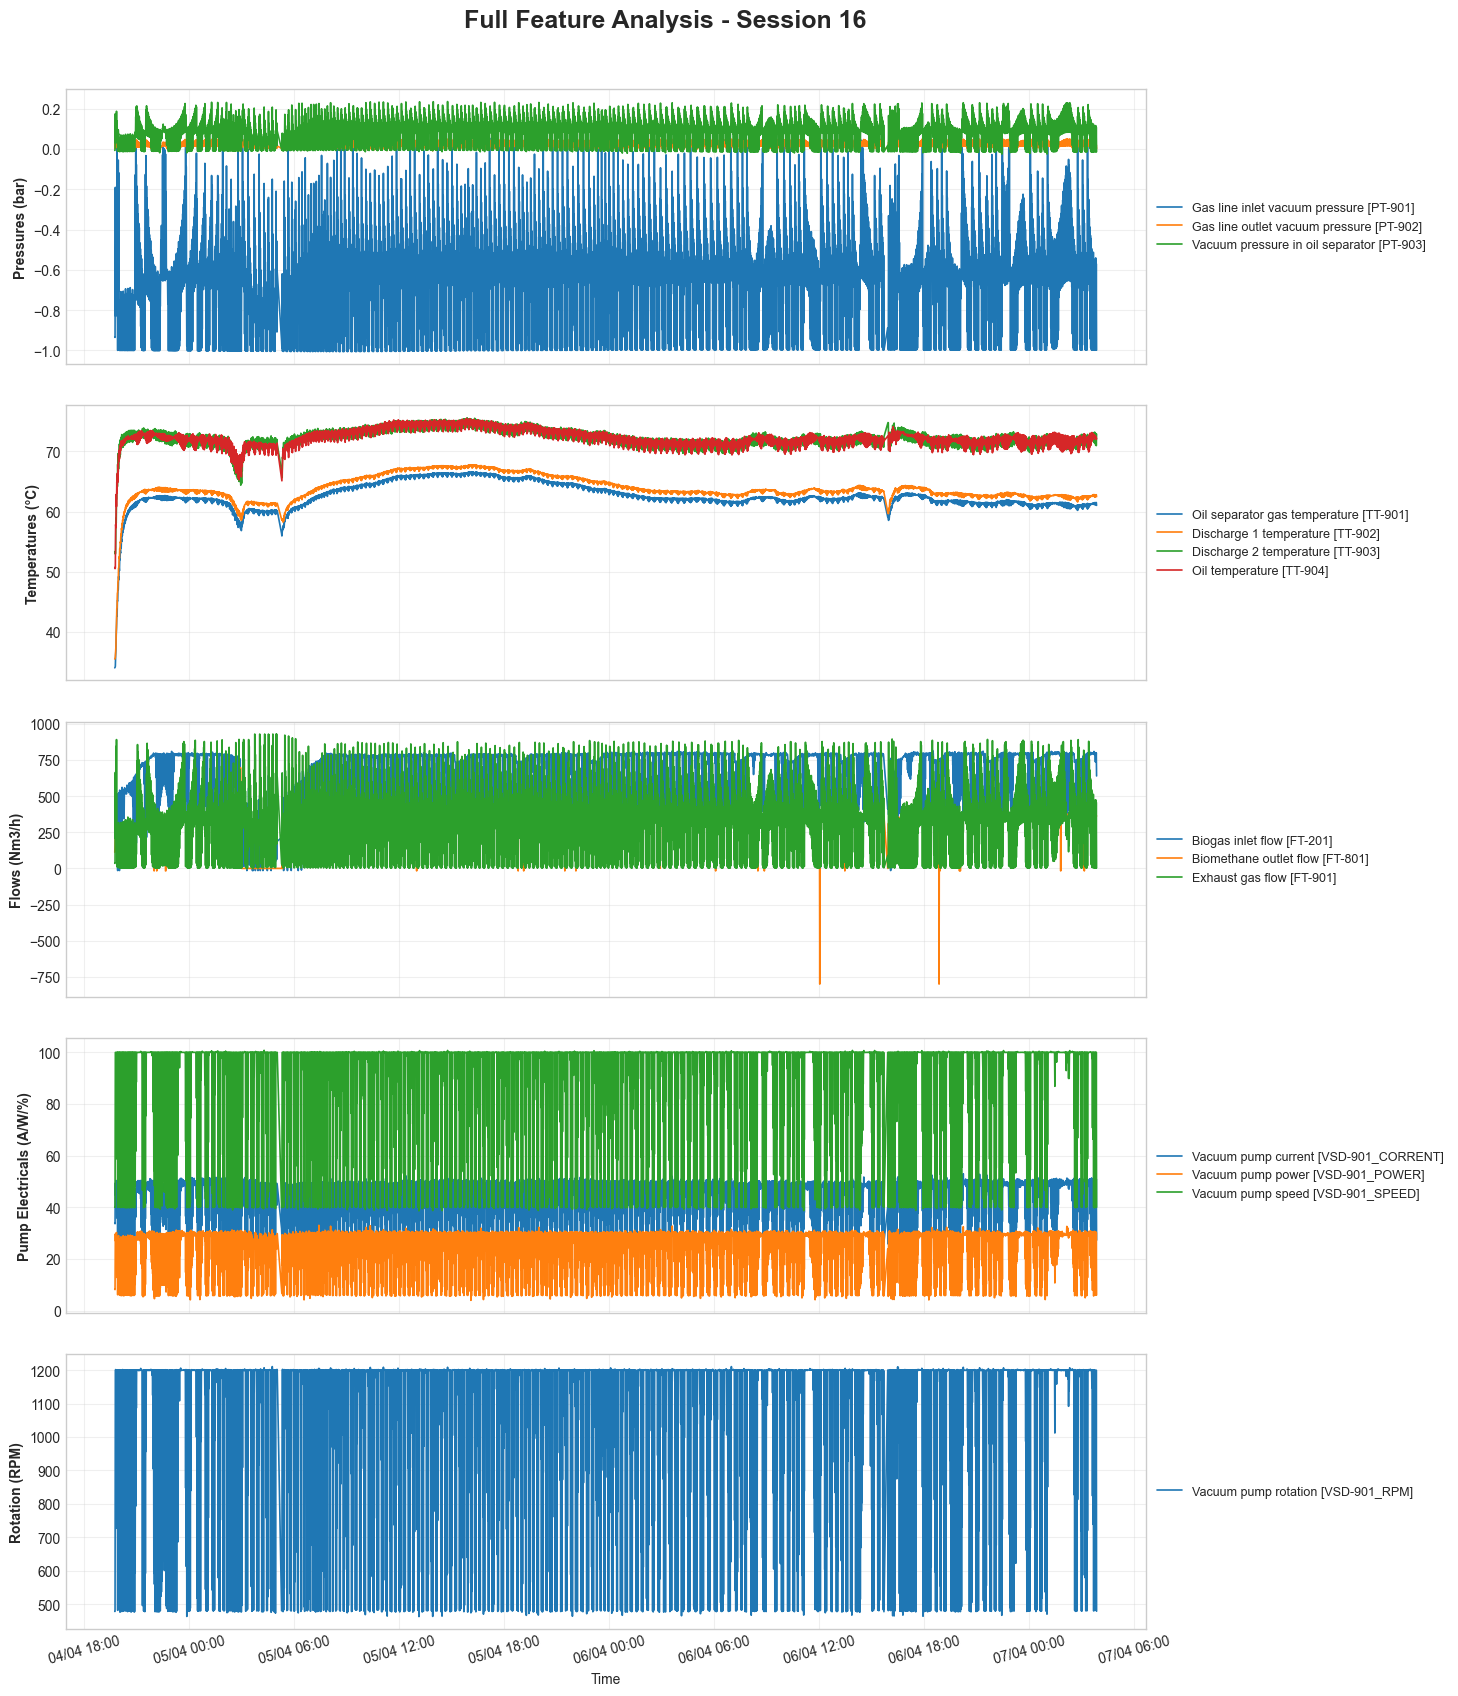

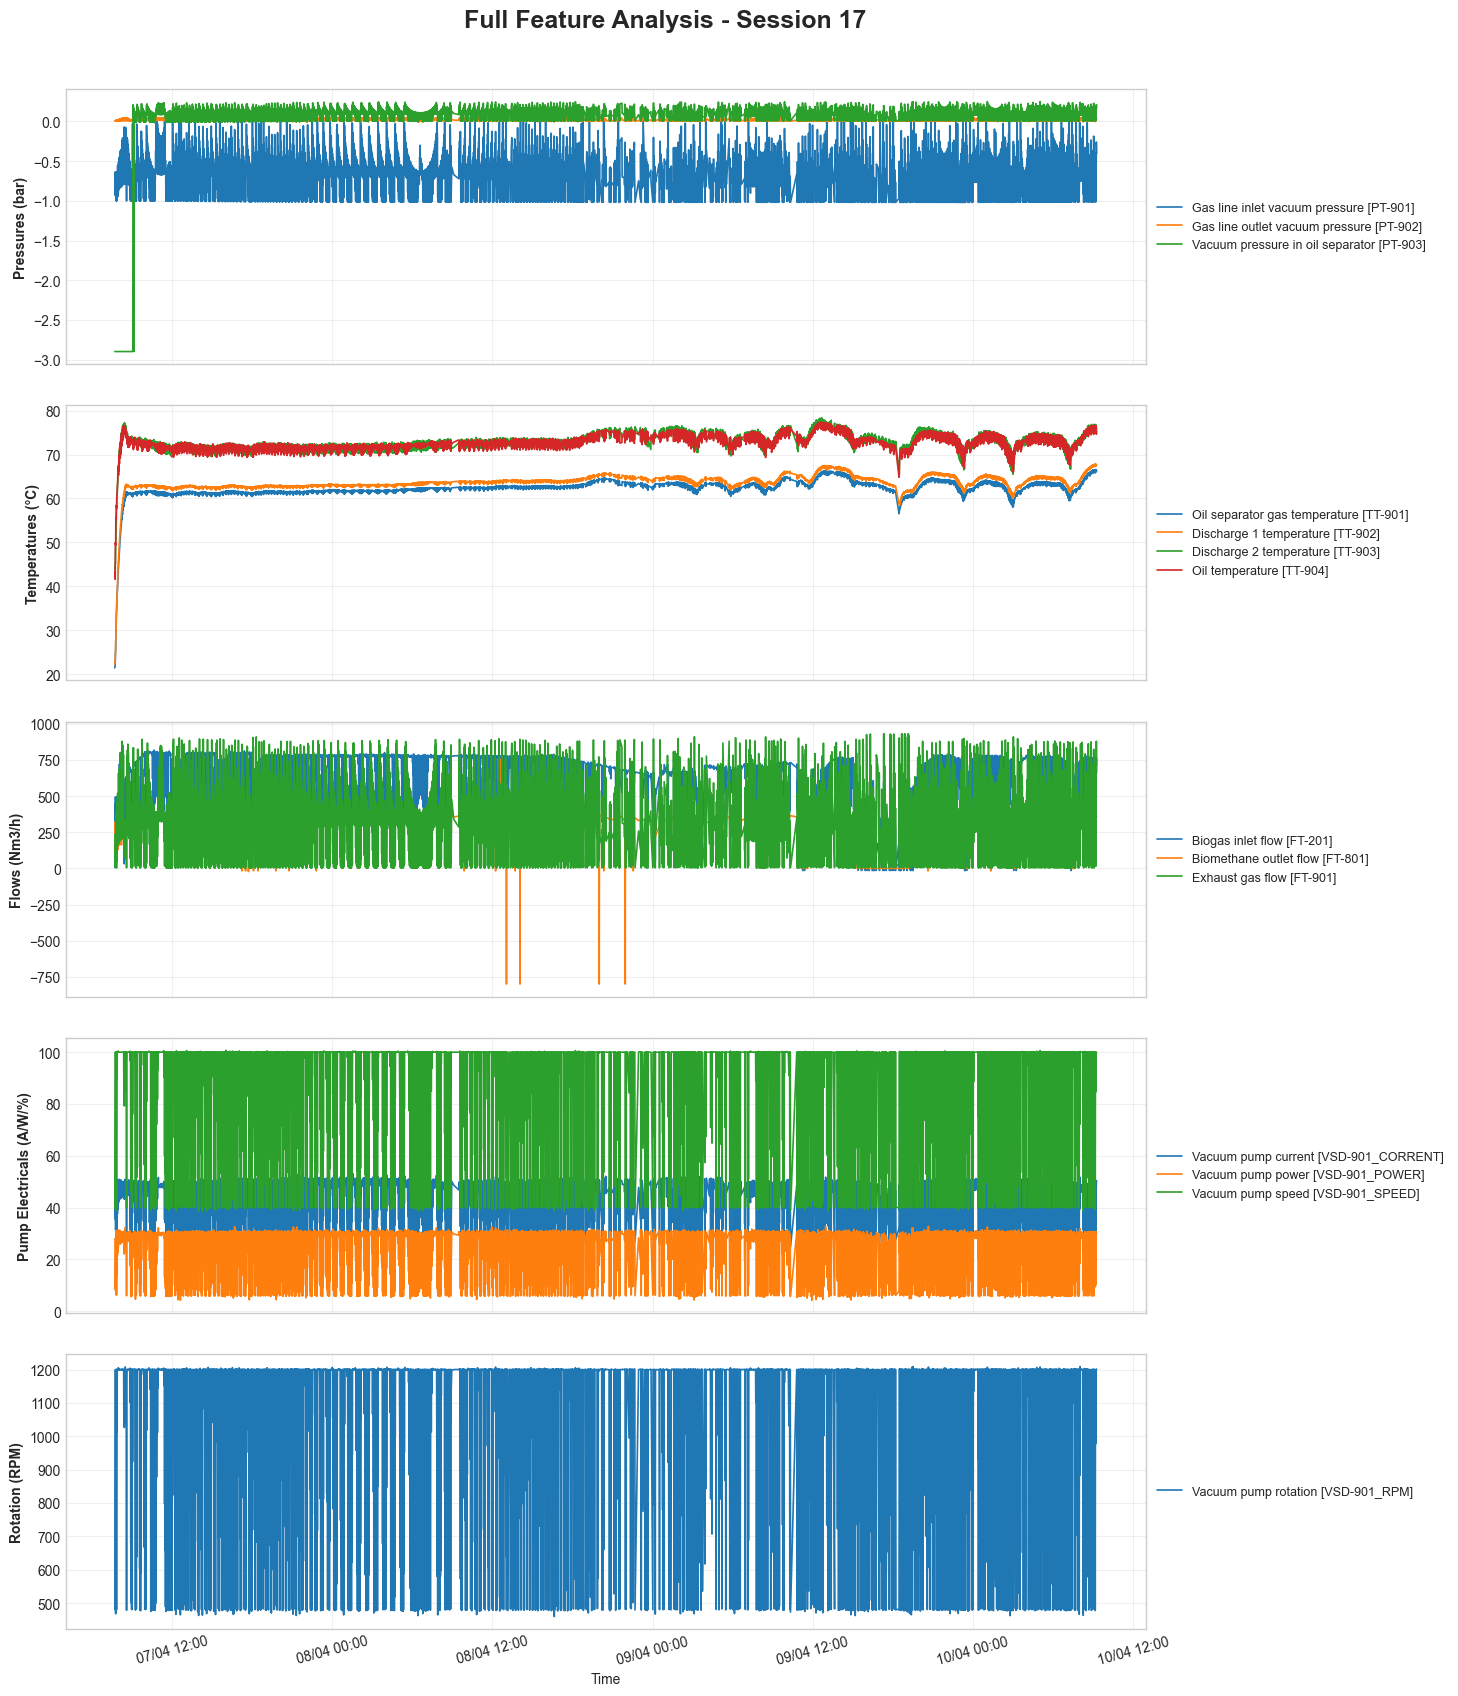

In [13]:
# Definir os grupos de colunas para iterar
groups = [
    ("Pressures (bar)", pressure_cols),
    ("Temperatures (°C)", temp_cols),
    ("Flows (Nm3/h)", flow_cols),
    ("Pump Electricals (A/W/%)", pump_current_cols + pump_power_cols + pump_speed_cols),
    ("Rotation (RPM)", pump_rpm_cols)
]

plt.style.use('seaborn-v0_8-whitegrid')

for s_id, df in dict_sessions.items():
    # Criar uma figura com 5 subplots (um para cada grupo)
    fig, axes = plt.subplots(nrows=len(groups), ncols=1, figsize=(16, 20), sharex=True, dpi=100)
    fig.suptitle(f"Full Feature Analysis - Session {s_id}", fontsize=18, fontweight='bold', y=0.92)

    for ax, (title, cols) in zip(axes, groups):
        for col in cols:
            if col in df.columns:
                label = f"{TAG_INFO[col]['label']} [{col}]"
                ax.plot(df.index, df[col], label=label, linewidth=1.2)
        
        ax.set_ylabel(title, fontsize=10, fontweight='bold')
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
        ax.grid(True, alpha=0.3)

    # Formatar o eixo do tempo no último gráfico
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    plt.xticks(rotation=15)
    
    plt.xlabel("Time")
    plt.subplots_adjust(right=0.8, hspace=0.15) # Dar espaço para as legendas à direita
    plt.show()

A: Obstrução Gradual (Filtros de Exaustão ou Entrada):

O que acontece: O manual diz que isto causa aquecimento e perda de pressão.

Simulação: Sobe a PT-903 (pressão no separador) em direção ao Trip (0.5 mbar). Como a bomba faz mais esforço, as temperaturas TT-901 a TT-904 sobem proporcionalmente.

B: Nível de Óleo Baixo (Low Oil Level):

O que acontece: Causa aquecimento excessivo e fumo.

Simulação: O sensor LS-901 passa a False (ou 0). Imediatamente após, injetas uma rampa de subida rápida na TT-904 (óleo) e TT-902/903 (descargas).

C: Falha no Sistema de Arrefecimento (Insufficient Cooling):

O que acontece: Máquina corre "too hot".

Simulação: Injetar um aumento em todas as TT, mas especialmente na TT-901 (gás no separador), aproximando-a dos 135ºC-140ºC.


O algoritmo deve ser:
Calcular a matriz de correlação nos dados "saudáveis" (os outros 15 baldes).
Definir o sensor "âncora" da falha (ex: TT-904).Injetar o aumento no âncora.
Propagar o aumento para os sensores correlacionados usando o coeficiente de correlação ($r$).$$Valor_{novo} = Valor_{original} + (Delta_{âncora} \times r)$$



talvez seja uma boa ideia aprender os warnings, de modo a prever "RUL" antes do trips, ou seja, anomalia nos warnings, propago/estimo valores no futuro, e com isso faço uma previsão do RUL